### Librerias

In [ ]:
import random
import numpy as np
import keras
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Lambda, Conv2D, AveragePooling2D, BatchNormalization
from tensorflow.keras.utils import plot_model

### Funciones

In [ ]:
def make_pairs(x, y):
    """Creates a tuple containing image pairs with corresponding label.

    Arguments:
        x: List containing images, each index in this list corresponds to one image.
        y: List containing labels, each label with datatype of `int`.

    Returns:
        Tuple containing two numpy arrays as (pairs_of_samples, labels),
        where pairs_of_samples' shape is (2len(x), 2,n_features_dims) and
        labels are a binary array of shape (2len(x)).
    """

    num_classes = max(y) + 1
    digit_indices = [np.where(y == i)[0] for i in range(num_classes)]

    pairs = []
    labels = []

    for idx1 in range(len(x)):
        # add a matching example
        x1 = x[idx1]
        label1 = y[idx1]
        idx2 = random.choice(digit_indices[label1])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [0]

        # add a non-matching example
        label2 = random.randint(0, num_classes - 1)
        while label2 == label1:
            label2 = random.randint(0, num_classes - 1)

        idx2 = random.choice(digit_indices[label2])
        x2 = x[idx2]

        pairs += [[x1, x2]]
        labels += [1]

    return np.array(pairs), np.array(labels).astype("float32")



In [ ]:
def euclidean_distance(vects):
    x, y = vects
    sum_square = tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True)
    return tf.sqrt(tf.maximum(sum_square, tf.keras.backend.epsilon()))

def contrastive_loss(y_true, y_pred, margin=1):
    square_pred = tf.square(y_pred)
    margin_square = tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean((1 - y_true) * square_pred + y_true * margin_square)

In [ ]:
def plt_metric(history, metric, title, has_valid=True):
    """Plots the given 'metric' from 'history'.

    Arguments:
        history: history attribute of History object returned from Model.fit.
        metric: Metric to plot, a string value present as key in 'history'.
        title: A string to be used as title of plot.
        has_valid: Boolean, true if valid data was passed to Model.fit else false.

    Returns:
        None.
    """
    plt.plot(history[metric])
    if has_valid:
        plt.plot(history["val_" + metric])
        plt.legend(["train", "validation"], loc="upper left")
    plt.title(title)
    plt.ylabel(metric)
    plt.xlabel("epoch")
    plt.show()


In [ ]:
def visualize(pairs, labels, to_show=6, num_col=3, predictions=None, test=False):
    """Creates a plot of pairs and labels, and prediction if it's test dataset.

    Arguments:
        pairs: Numpy Array, of pairs to visualize, having shape
               (Number of pairs, 2, 28, 28).
        to_show: Int, number of examples to visualize (default is 6)
                `to_show` must be an integral multiple of `num_col`.
                 Otherwise it will be trimmed if it is greater than num_col,
                 and incremented if if it is less then num_col.
        num_col: Int, number of images in one row - (default is 3)
                 For test and train respectively, it should not exceed 3 and 7.
        predictions: Numpy Array of predictions with shape (to_show, 1) -
                     (default is None)
                     Must be passed when test=True.
        test: Boolean telling whether the dataset being visualized is
              train dataset or test dataset - (default False).

    Returns:
        None.
    """

    # Define num_row
    # If to_show % num_col != 0
    #    trim to_show,
    #       to trim to_show limit num_row to the point where
    #       to_show % num_col == 0
    #
    # If to_show//num_col == 0
    #    then it means num_col is greater then to_show
    #    increment to_show
    #       to increment to_show set num_row to 1
    num_row = to_show // num_col if to_show // num_col != 0 else 1

    # `to_show` must be an integral multiple of `num_col`
    #  we found num_row and we have num_col
    #  to increment or decrement to_show
    #  to make it integral multiple of `num_col`
    #  simply set it equal to num_row * num_col
    to_show = num_row * num_col

    # Plot the images
    fig, axes = plt.subplots(num_row, num_col, figsize=(5, 5))
    for i in range(to_show):
        # If the number of rows is 1, the axes array is one-dimensional
        if num_row == 1:
            ax = axes[i % num_col]
        else:
            ax = axes[i // num_col, i % num_col]

        ax.imshow(tf.concat([pairs[i][0], pairs[i][1]], axis=1), cmap="gray")
        ax.set_axis_off()
        if test:
            ax.set_title("True: {} | Pred: {:.5f}".format(labels[i], predictions[i][0]))
        else:
            ax.set_title("Label: {}".format(labels[i]))
    if test:
        plt.tight_layout(rect=(0, 0, 1.9, 1.9), w_pad=0.0)
    else:
        plt.tight_layout(rect=(0, 0, 1.5, 1.5))
    plt.show()


### Codigo

In [ ]:
epochs = 10
batch_size = 16
margin = 1  # Margin for contrastive loss.

In [ ]:
(x_train_val, y_train_val), (x_test, y_test) = keras.datasets.mnist.load_data()

# Change the data type to a floating point format
x_train_val = x_train_val.astype("float32")
x_test = x_test.astype("float32")

In [ ]:
# Keep 50% of train_val  in validation set
x_train, x_val = x_train_val[:30000], x_train_val[30000:]
y_train, y_val = y_train_val[:30000], y_train_val[30000:]
del x_train_val, y_train_val

In [ ]:

# make train pairs
pairs_train, labels_train = make_pairs(x_train, y_train)

# make validation pairs
pairs_val, labels_val = make_pairs(x_val, y_val)

# make test pairs
pairs_test, labels_test = make_pairs(x_test, y_test)

In [ ]:
x_train_1 = pairs_train[:, 0]  # x_train_1.shape is (60000, 28, 28)
x_train_2 = pairs_train[:, 1]

In [ ]:
x_val_1 = pairs_val[:, 0]  # x_val_1.shape = (60000, 28, 28)
x_val_2 = pairs_val[:, 1]

In [ ]:
x_test_1 = pairs_test[:, 0]  # x_test_1.shape = (20000, 28, 28)
x_test_2 = pairs_test[:, 1]

In [ ]:


# Definir la entrada para los pares de imágenes
input_shape = (28, 28, 1)  # Ajusta el tamaño según tus datos



In [ ]:
def create_siamese_network(input_shape):
    model_input = Input(shape=input_shape)

    # Capas convolucionales
    x = BatchNormalization()(model_input)
    x = Conv2D(4, (5, 5), activation="tanh")(x)
    x = AveragePooling2D(pool_size=(2, 2))(x)
    x = Conv2D(16, (5, 5), activation="tanh")(x)
    x = AveragePooling2D(pool_size=(2, 2))(x)

    # Capas completamente conectadas
    x = Flatten()(x)
    x = BatchNormalization()(x)
    x = Dense(10, activation="tanh")(x)
    #model_output = Dense(16, activation='sigmoid')(x)
    model_output = Dense(1, activation='sigmoid')(x)

    return Model(model_input, model_output)

In [ ]:
# Crear las dos ramas de la red siamesa
input_a = Input(shape=input_shape)
input_b = Input(shape=input_shape)

siamese_branch = create_siamese_network(input_shape)

# Aplicar las ramas siamesas a las entradas
output_a = siamese_branch(input_a)
output_b = siamese_branch(input_b)

# Calcular la distancia euclidiana entre las salidas de las ramas
distance = Lambda(euclidean_distance, output_shape=(1,))([output_a, output_b])

# Construir el modelo siamesa final
siamese = Model(inputs=[input_a, input_b], outputs=distance)


In [ ]:
siamese.compile(loss=lambda y_true, y_pred: contrastive_loss(y_true, y_pred, margin=1),
                optimizer="RMSprop", metrics=["accuracy"])

In [ ]:
siamese.compile(loss=lambda y_true, y_pred: contrastive_loss(y_true, y_pred, margin=1),
                optimizer="adam", metrics=["accuracy"])

In [ ]:
# Suponiendo que tienes datos de entrenamiento en train_data_pair y etiquetas correspondientes en train_labels
history = siamese.fit([x_train_1, x_train_2], labels_train, validation_data=([x_val_1, x_val_2], labels_val) ,epochs=5, batch_size=25)

Epoch 1/5
2400/2400 [==============================] - 81s 33ms/step - loss: 0.2344 - accuracy: 0.6766 - val_loss: 0.2139 - val_accuracy: 0.7137
Epoch 2/5
2400/2400 [==============================] - 78s 33ms/step - loss: 0.2091 - accuracy: 0.7180 - val_loss: 0.1998 - val_accuracy: 0.7352
Epoch 3/5
2400/2400 [==============================] - 72s 30ms/step - loss: 0.1990 - accuracy: 0.7318 - val_loss: 0.1941 - val_accuracy: 0.7342
Epoch 4/5
2400/2400 [==============================] - 77s 32ms/step - loss: 0.1930 - accuracy: 0.7365 - val_loss: 0.1930 - val_accuracy: 0.7345
Epoch 5/5
2400/2400 [==============================] - 76s 32ms/step - loss: 0.1899 - accuracy: 0.7398 - val_loss: 0.1931 - val_accuracy: 0.7324


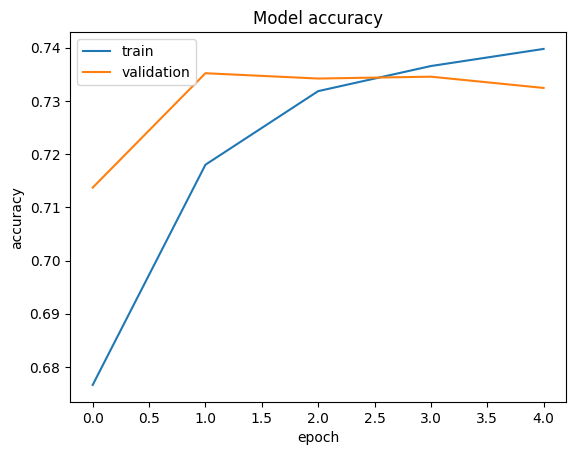

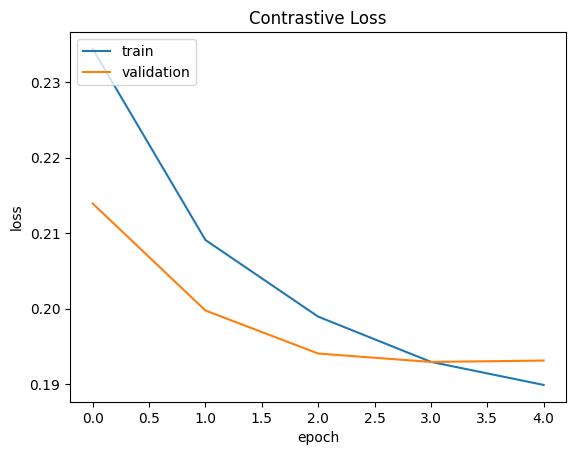

In [ ]:
# Plot the accuracy
plt_metric(history=history.history, metric="accuracy", title="Model accuracy")

# Plot the contrastive loss
plt_metric(history=history.history, metric="loss", title="Contrastive Loss")

In [ ]:
results = siamese.evaluate([x_test_1, x_test_2], labels_test)
print("test loss, test acc:", results)

625/625 [==============================] - 6s 10ms/step - loss: 0.1925 - accuracy: 0.7352
test loss, test acc: [0.1925215870141983, 0.7351999878883362]


In [ ]:
predictions = siamese.predict([x_test_1, x_test_2])

625/625 [==============================] - 5s 8ms/step


In [ ]:
predictions

array([[3.1622776e-04],
       [1.6984683e-01],
       [3.4571290e-03],
       ...,
       [9.8930413e-01],
       [1.6693171e-02],
       [9.7527641e-01]], dtype=float32)

In [ ]:
max(predictions)

array([0.99753404], dtype=float32)

In [ ]:
predictions.shape

(20000, 1)

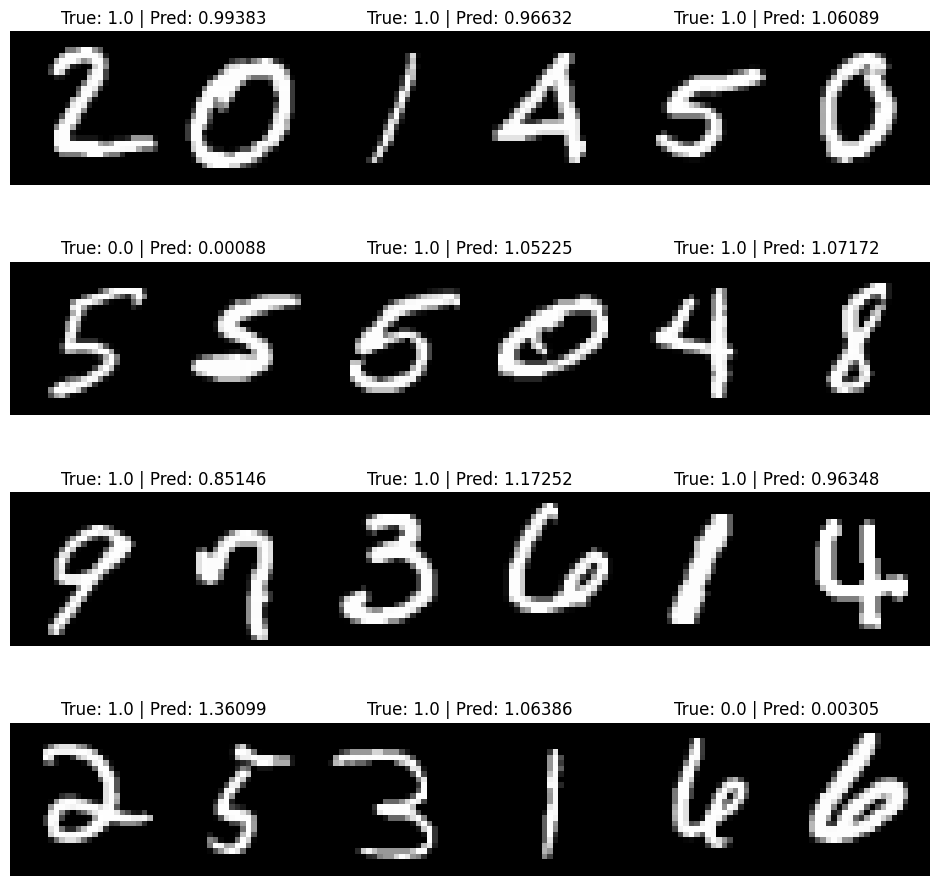

In [ ]:
sample_size = 12
sample_indices = np.random.choice(len(labels_test), size=sample_size, replace=False)

# Visualizar la muestra
visualize(pairs_test[sample_indices], labels_test[sample_indices], to_show=sample_size, predictions=predictions[sample_indices], test=True)

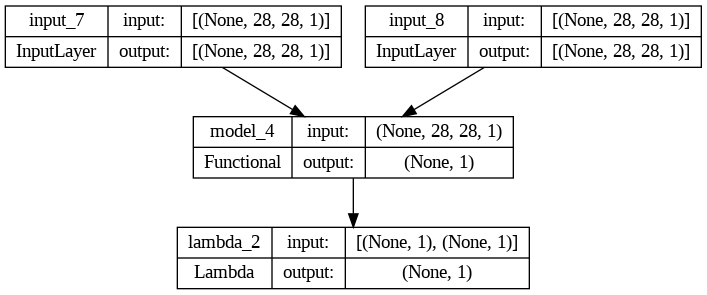

In [ ]:
# Supongamos que 'siamese_model' es tu modelo siamesa
plot_model(siamese, to_file='siamese_model.png', show_shapes=True)